<a href="https://colab.research.google.com/github/Hemoonchild/Iranian-License-Plate-Recognition/blob/main/main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Step 1: LPD Dataset Preparation & Configuration
- **Download & Storage Strategy**: The raw dataset archive (`LPD.zip`) is archived in Google Drive to prevent re-download quota limits and extracted locally to `/content/` for fast SSD I/O.
- **Visual Inspection**: Verified bounding box alignment on sample images (class 0: `license_plate`) using OpenCV and Matplotlib.
- **Split Strategy**: Split 6,252 images into an **85% train** (5,314 samples) and **15% val** (938 samples) partition using symbolic links to prevent disk duplication.
- **Configuration**: Created `data.yaml` conforming to the Ultralytics YOLO format specifying dataset paths and single-class detection.

In [1]:
# 1. Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# 2. Create a directory on Drive for persisting checkpoints
import os
CHECKPOINT_DIR = '/content/drive/MyDrive/License_Plate_Project'
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
print(f"Checkpoints will be saved to: {CHECKPOINT_DIR}")

# 3. Verify GPU
import torch
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"Device Name: {torch.cuda.get_device_name(0)}")

Mounted at /content/drive
Checkpoints will be saved to: /content/drive/MyDrive/License_Plate_Project
CUDA available: False


In [2]:
import os
import shutil
import gdown
from pathlib import Path

# Paths
DRIVE_DIR = "/content/drive/MyDrive/License_Plate_Project"
os.makedirs(DRIVE_DIR, exist_ok=True)

drive_lpd_zip = os.path.join(DRIVE_DIR, "LPD.zip")
local_lpd_zip = "/content/LPD.zip"
extract_dir = "/content/LPD_RAW"

# 1. Download LPD.zip into Google Drive if not already present
LPD_FILE_ID = "1UBV930A9pRhVwop-WunmP38th2XwEumx"
if not os.path.exists(drive_lpd_zip):
    print("Downloading LPD.zip to Google Drive (one-time setup)...")
    gdown.download(id=LPD_FILE_ID, output=drive_lpd_zip, quiet=False)
else:
    print("LPD.zip already exists in your Google Drive!")

# 2. Copy from Google Drive to Colab local SSD
print("Copying LPD.zip to local Colab SSD...")
shutil.copy(drive_lpd_zip, local_lpd_zip)

# 3. Unzip locally (fast)
print("Extracting LPD.zip locally...")
os.makedirs(extract_dir, exist_ok=True)
!unzip -q {local_lpd_zip} -d {extract_dir}

print("Done extracting!")

Downloading...
From (original): https://drive.google.com/uc?id=1UBV930A9pRhVwop-WunmP38th2XwEumx
From (redirected): https://drive.google.com/uc?id=1UBV930A9pRhVwop-WunmP38th2XwEumx&confirm=t&uuid=e7c28553-191c-44ef-970a-5e0b2cad9cae
To: /content/drive/MyDrive/License_Plate_Project/LPD.zip
100%|██████████| 3.76G/3.76G [01:15<00:00, 49.5MB/s]


Copying LPD.zip to local Colab SSD...
Extracting LPD.zip locally...
Done extracting!


In [3]:
# Inspect directory structure
extracted_items = os.listdir(extract_dir)
print(f"Top-level contents of {extract_dir}:")
print(extracted_items[:10])

# Find sample files recursively
all_files = []
for root, dirs, files in os.walk(extract_dir):
    for f in files:
        all_files.append(os.path.relpath(os.path.join(root, f), extract_dir))

print(f"\nTotal files extracted: {len(all_files)}")
print("\nFirst 10 file paths found:")
for f in all_files[:10]:
    print(" -", f)

# Check extensions
from collections import Counter
extensions = Counter([os.path.splitext(f)[1].lower() for f in all_files])
print("\nFile extensions count:", extensions)

Top-level contents of /content/LPD_RAW:
['labels', 'plate_labels.csv', 'images']

Total files extracted: 12505

First 10 file paths found:
 - plate_labels.csv
 - labels/000693.txt
 - labels/002007.txt
 - labels/002102.txt
 - labels/005260.txt
 - labels/001632.txt
 - labels/003209.txt
 - labels/002312.txt
 - labels/002860.txt
 - labels/005186.txt

File extensions count: Counter({'.txt': 6252, '.jpg': 6252, '.csv': 1})


In [4]:
# 1. Read a sample txt label
sample_txt = "/content/LPD_RAW/labels/000693.txt"
with open(sample_txt, "r") as f:
    print(f"Content of {sample_txt}:")
    print(f.read())

# 2. Inspect the CSV file header
import pandas as pd
df = pd.read_csv("/content/LPD_RAW/plate_labels.csv")
print("First 5 rows of plate_labels.csv:")
print(df.head())

Content of /content/LPD_RAW/labels/000693.txt:
0 0.4615885416666667 0.0484375 0.12890625 0.025

First 5 rows of plate_labels.csv:
   index  image_path     label
0      1  000001.jpg  48و15116
1      2  000002.jpg  78س92616
2      3  000003.jpg  73ب31536
3      4  000004.jpg  35و33669
4      5  000005.jpg  39ص29449


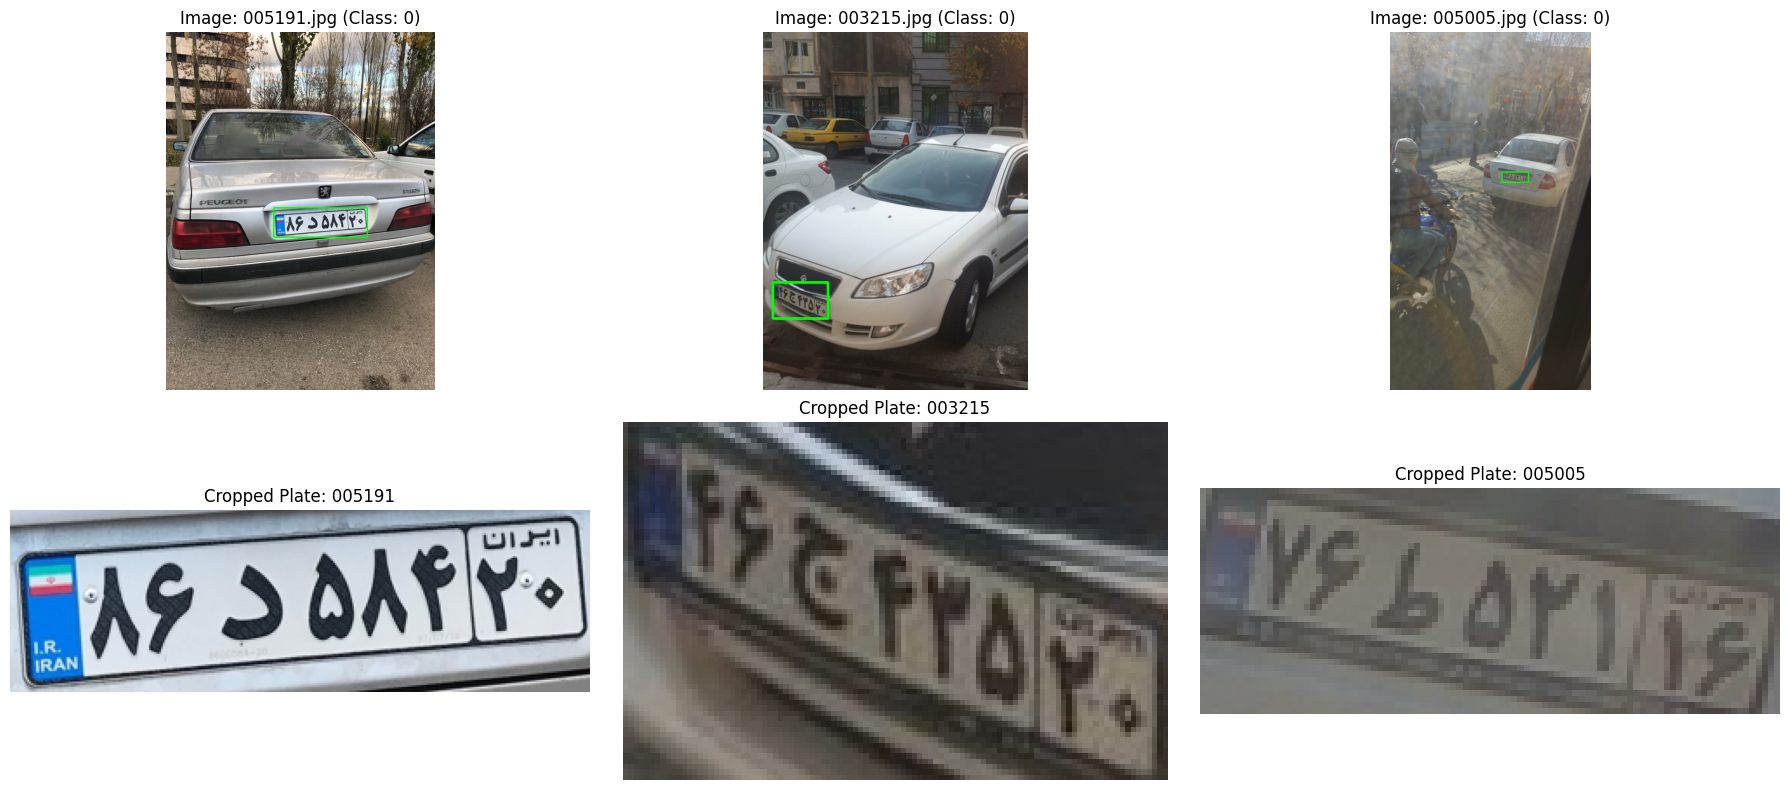

In [7]:
import os
import random
import cv2
import matplotlib.pyplot as plt

# Get list of all image base names that have corresponding labels
raw_img_dir = "/content/LPD_RAW/images"
raw_lbl_dir = "/content/LPD_RAW/labels"

valid_stems = [
    os.path.splitext(f)[0]
    for f in os.listdir(raw_img_dir)
    if os.path.exists(os.path.join(raw_lbl_dir, os.path.splitext(f)[0] + ".txt"))
]

# Pick 3 random images (fixed seed for reproducibility, change or remove seed to see different ones)
random.seed(2002)
sampled_stems = random.sample(valid_stems, 3)

fig, axes = plt.subplots(2, 3, figsize=(18, 8))

for col_idx, stem in enumerate(sampled_stems):
    img_path = os.path.join(raw_img_dir, f"{stem}.jpg")
    lbl_path = os.path.join(raw_lbl_dir, f"{stem}.txt")

    img = cv2.imread(img_path)
    h, w, _ = img.shape

    with open(lbl_path, "r") as f:
        line = f.readline().strip().split()
        cls, x_c, y_c, bw, bh = int(line[0]), float(line[1]), float(line[2]), float(line[3]), float(line[4])

    # Calculate pixel coords
    xmin = max(0, int((x_c - bw / 2) * w))
    ymin = max(0, int((y_c - bh / 2) * h))
    xmax = min(w, int((x_c + bw / 2) * w))
    ymax = min(h, int((y_c + bh / 2) * h))

    # Image with bounding box
    img_with_box = img.copy()
    cv2.rectangle(img_with_box, (xmin, ymin), (xmax, ymax), (0, 255, 0), 3)

    # Top row: Full image with bounding box
    axes[0, col_idx].imshow(cv2.cvtColor(img_with_box, cv2.COLOR_BGR2RGB))
    axes[0, col_idx].set_title(f"Image: {stem}.jpg (Class: {cls})", fontsize=12)
    axes[0, col_idx].axis("off")

    # Bottom row: Cropped plate
    cropped_plate = img[ymin:ymax, xmin:xmax]
    if cropped_plate.size > 0:
        axes[1, col_idx].imshow(cv2.cvtColor(cropped_plate, cv2.COLOR_BGR2RGB))
    axes[1, col_idx].set_title(f"Cropped Plate: {stem}", fontsize=12)
    axes[1, col_idx].axis("off")

plt.tight_layout()
plt.show()

In [9]:
import os
import random
from tqdm import tqdm

# Set seed for reproducible split
random.seed(42)

# Paths
base_output_dir = "/content/LPD_FILES"
train_img_dir = os.path.join(base_output_dir, "images", "train")
val_img_dir = os.path.join(base_output_dir, "images", "val")
train_lbl_dir = os.path.join(base_output_dir, "labels", "train")
val_lbl_dir = os.path.join(base_output_dir, "labels", "val")

# Clean and recreate directories
for d in [train_img_dir, val_img_dir, train_lbl_dir, val_lbl_dir]:
    os.makedirs(d, exist_ok=True)

# Pair up all images that have valid label files
all_stems = [
    os.path.splitext(f)[0]
    for f in os.listdir("/content/LPD_RAW/images")
    if os.path.exists(os.path.join("/content/LPD_RAW/labels", os.path.splitext(f)[0] + ".txt"))
]

random.shuffle(all_stems)

# 85% train, 15% validation split
split_idx = int(0.85 * len(all_stems))
train_stems = set(all_stems[:split_idx])
val_stems = set(all_stems[split_idx:])

print(f"Total samples: {len(all_stems)}")
print(f"Train samples (85%): {len(train_stems)}")
print(f"Val samples   (15%): {len(val_stems)}")

# Link images and labels to their respective split directories
def link_files(stems, target_img_dir, target_lbl_dir):
    for stem in tqdm(stems):
        src_img = os.path.join("/content/LPD_RAW/images", f"{stem}.jpg")
        src_lbl = os.path.join("/content/LPD_RAW/labels", f"{stem}.txt")

        dst_img = os.path.join(target_img_dir, f"{stem}.jpg")
        dst_lbl = os.path.join(target_lbl_dir, f"{stem}.txt")

        if not os.path.exists(dst_img):
            os.symlink(src_img, dst_img)
        if not os.path.exists(dst_lbl):
            os.symlink(src_lbl, dst_lbl)

print("\nCreating Train split...")
link_files(train_stems, train_img_dir, train_lbl_dir)

print("Creating Val split...")
link_files(val_stems, val_img_dir, val_lbl_dir)

print("\nSplit successfully completed!")

Total samples: 6252
Train samples (85%): 5314
Val samples   (15%): 938

Creating Train split...


100%|██████████| 5314/5314 [00:00<00:00, 14631.80it/s]


Creating Val split...


100%|██████████| 938/938 [00:00<00:00, 16017.66it/s]


Split successfully completed!


In [10]:
import yaml

data_yaml_content = {
    'path': '/content/LPD_FILES',
    'train': 'images/train',
    'val': 'images/val',
    'nc': 1,
    'names': ['license_plate']
}

yaml_path = '/content/data.yaml'
with open(yaml_path, 'w') as f:
    yaml.dump(data_yaml_content, f, sort_keys=False)

print(f"data.yaml created at {yaml_path}:")
with open(yaml_path, 'r') as f:
    print(f.read())

data.yaml created at /content/data.yaml:
path: /content/LPD_FILES
train: images/train
val: images/val
nc: 1
names:
- license_plate

